In [ ]:
# !pip install 
# !pip install nltk 
# ! python -m spacy download en_core_web_sm

# Iman Noor
---
<h1 style="font-size:36px; font-family:Verdana, sans-serif; color:navy; text-align:center; font-weight:bold;">
    ADVANCED NLP TECHNIQUES (NER, SENTIMENT ANALYSIS)
</h1>
<h1 style="font-size:25px; font-family:Verdana, sans-serif; color:darkgreen; font-weight:bold;">
    NAMED ENTITY RECOGNITION (NER)
</h1>

Named Entity Recognition (NER) is a technique in natural language processing (NLP) that focuses on identifying and classifying entities. The purpose of NER is to automatically extract structured information from unstructured text, enabling machines to understand and categorize entities in a meaningful manner for various applications like text summarization, building knowledge graphs, question answering, and knowledge graph construction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import requests
from bs4 import BeautifulSoup
nlp = spacy.load('en_core_web_sm')
pd.set_option('display.max_rows', 200)

In [2]:
content = (
    "NASA's Perseverance rover has successfully landed on Mars, marking a historic achievement in space exploration. "
    "The rover's primary mission is to search for signs of ancient life and collect samples of rock and regolith. "
    "This landing is part of NASA's broader Mars Exploration Program, which aims to understand the planet's geology and "
    "potential for habitability. The Perseverance rover will also prepare for future human exploration of Mars."
)
doc = nlp(content)

In [3]:
for ent in doc.ents:
        print(ent.text, ent.start_char, ent.end_char, ent.label_)

NASA 0 4 ORG
Mars 53 57 LOC
NASA 245 249 ORG
Mars Exploration Program 260 284 ORG
Perseverance 368 380 ORG
Mars 437 441 LOC


# **Visualization**
The `displacy.render` function from spaCy is utilized to visualize named entities within a text. It creates a graphical representation where recognized entities are highlighted with different colors, each corresponding to their respective categories.

In [4]:
from spacy import displacy
displacy.render(doc, style="ent")

Now, we'll create a dataframe that will include text, type(label) and lemma of each entity.

In [5]:
entities = [(ent.text, ent.label_, ent.lemma_) for ent in doc.ents]
data = pd.DataFrame(entities, columns=['text', 'type', 'lemma'])
data

,text,type,lemma
0,NASA,ORG,NASA
1,Mars,LOC,Mars
2,NASA,ORG,NASA
3,Mars Exploration Program,ORG,Mars Exploration Program
4,Perseverance,ORG,Perseverance
5,Mars,LOC,Mars


In [6]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

/opt/conda/lib/python3.10/site-packages/nltk/twitter/__init__.py:20: UserWarning: The twython library has not been installed. Some functionality from the twitter package will not be available.
  warnings.warn("The twython library has not been installed. "


In [7]:
# nltk.download('vader_lexicon')

In [8]:
# Initialize SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

In [9]:
def analyze_sentiment(content):
    # Analyze sentiment using NLTK's SentimentIntensityAnalyzer
    sentiment = sia.polarity_scores(content)
    return sentiment

In [10]:
# Perform Sentiment Analysis
sentiment = analyze_sentiment(content)
print("\nSentiment Analysis:")
print(f"Positive: {sentiment['pos']}")
print(f"Negative: {sentiment['neg']}")
print(f"Neutral: {sentiment['neu']}")
print(f"Compound: {sentiment['compound']}")


Sentiment Analysis:
Positive: 0.126
Negative: 0.0
Neutral: 0.874
Compound: 0.7845


In [11]:
text = """
The new smartphone model released by TechnoCorp has been receiving rave reviews from critics and users alike. 
Its innovative design, impressive battery life, and cutting-edge features have set a new standard in the industry. 
Many users have expressed their excitement and satisfaction with the device, praising its performance and value for money. 
However, there are some minor concerns about the device's high price, which some find a bit steep. 
Overall, the response has been overwhelmingly positive, with most users thrilled about their purchase.
"""

In [12]:
# Perform Sentiment Analysis
sentiment = analyze_sentiment(text)
print("\nSentiment Analysis:")
print(f"Positive: {sentiment['pos']}")
print(f"Negative: {sentiment['neg']}")
print(f"Neutral: {sentiment['neu']}")
print(f"Compound: {sentiment['compound']}")


Sentiment Analysis:
Positive: 0.251
Negative: 0.037
Neutral: 0.712
Compound: 0.9693


<h1 style="font-size:25px; font-family:Verdana, sans-serif; color:darkgreen; font-weight:bold;">
    SENTIMENT ANALYSIS
</h1>

1. VADER (Valence Aware Dictionary and Sentiment Reasoner) - Bag of words approach

2. Roberta Pretrained Model from🤗

3. Huggingface Pipeline

## **Step 0: Read in data and nltk basics**

In [13]:
import nltk

In [14]:
df = pd.read_csv('/kaggle/input/amazon-fine-food-reviews/Reviews.csv')
print("Original shape:", df.shape)
df = df.head(500)
print("After selection, the shape:", df.shape)

Original shape: (568454, 10)
After selection, the shape: (500, 10)


In [15]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## **Quick EDA**
Creating custom function to apply black background and white text.

In [16]:
def set_black_theme():
    plt.rcParams.update({
        'figure.facecolor': 'black',
        'axes.facecolor': 'black',
        'axes.edgecolor': 'white',
        'axes.labelcolor': 'white',
        'xtick.color': 'white',
        'ytick.color': 'white',
        'text.color': 'white',
        'axes.titlecolor': 'white'
    })

In [17]:
set_black_theme()

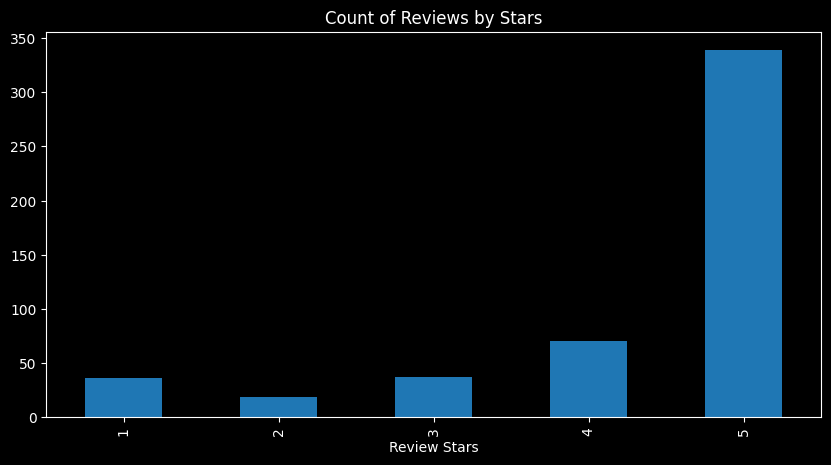

In [18]:
ax = df['Score'].value_counts().sort_index().plot(
    kind='bar',
    title='Count of Reviews by Stars',
    figsize=(10, 5)
)
ax.set_xlabel('Review Stars');

## **Basic NLTK**

In [19]:
example = df['Text'][50]
print(example)

This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go.


In [20]:
tokens = nltk.word_tokenize(example)
tokens[:10]

['This', 'oatmeal', 'is', 'not', 'good', '.', 'Its', 'mushy', ',', 'soft']

In [21]:
tagged = nltk.pos_tag(tokens)
tagged[:10]

[('This', 'DT'),
 ('oatmeal', 'NN'),
 ('is', 'VBZ'),
 ('not', 'RB'),
 ('good', 'JJ'),
 ('.', '.'),
 ('Its', 'PRP$'),
 ('mushy', 'NN'),
 (',', ','),
 ('soft', 'JJ')]

In [22]:
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

(S
  This/DT
  oatmeal/NN
  is/VBZ
  not/RB
  good/JJ
  ./.
  Its/PRP$
  mushy/NN
  ,/,
  soft/JJ
  ,/,
  I/PRP
  do/VBP
  n't/RB
  like/VB
  it/PRP
  ./.
  (ORGANIZATION Quaker/NNP Oats/NNPS)
  is/VBZ
  the/DT
  way/NN
  to/TO
  go/VB
  ./.)


## **Step 1: VADER Sentiment Scoring**

NLTK's `SentimentIntensityAnalyzer` will be used to calculate the negative, neutral, and positive sentiment scores for the text.

This process employs a "bag of words" method:
- Stop words are removed
- Each remaining word is individually scored
- The scores are then aggregated to generate an overall sentiment score

In [23]:
import warnings
warnings.filterwarnings("ignore", message="The twython library has not been installed. ")

In [24]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

sia = SentimentIntensityAnalyzer()

In [25]:
sia

In [26]:
sia.polarity_scores('I really hate you!')

{'neg': 0.682, 'neu': 0.318, 'pos': 0.0, 'compound': -0.6468}

In [27]:
sia.polarity_scores('I am so happy!')

{'neg': 0.0, 'neu': 0.318, 'pos': 0.682, 'compound': 0.6468}

In [28]:
sia.polarity_scores('I love listening to lies when I know the truth.')

{'neg': 0.196, 'neu': 0.35, 'pos': 0.455, 'compound': 0.5719}

In [29]:
sia.polarity_scores(example)

{'neg': 0.22, 'neu': 0.78, 'pos': 0.0, 'compound': -0.5448}

*Running polarity on the entire dataset*

In [30]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Text']
    myid = row['Id']
    res[myid] = sia.polarity_scores(text)

  0%|          | 0/500 [00:00<?, ?it/s]

In [31]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'Id'})
vaders = vaders.merge(df, how='left')

In [32]:
vaders.head()

,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.079,0.853,0.068,-0.1027,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


### **Plot VADER results**

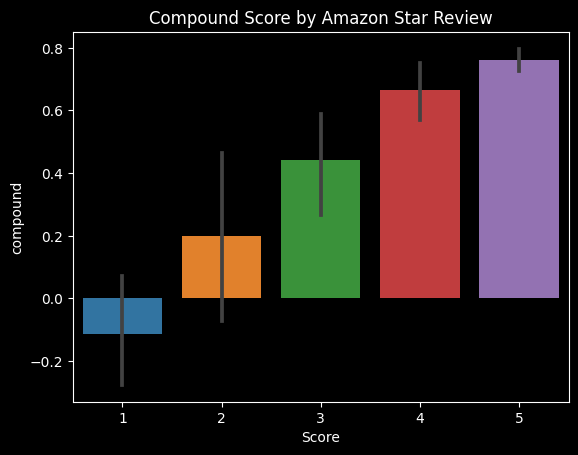

In [33]:
ax = sns.barplot(data=vaders, x='Score', y='compound')
ax.set_title('Compound Score by Amazon Star Review')
plt.show();

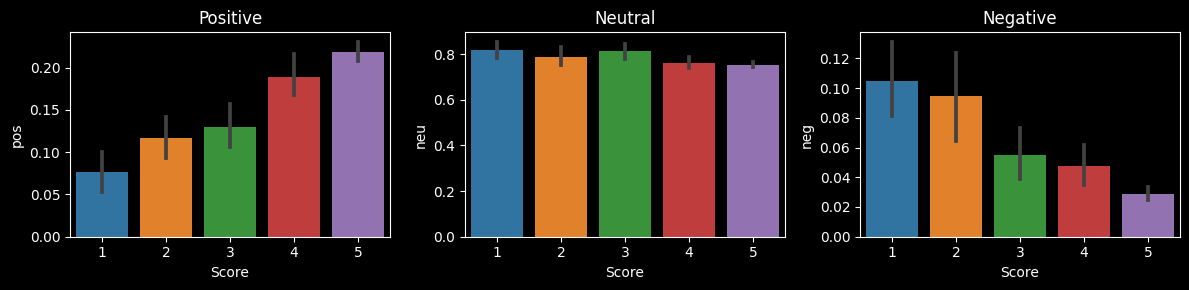

In [34]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.barplot(data=vaders, x='Score', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='Score', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='Score', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()

## **Step 2: Roberta Pretrained Model**

- Utilize a model trained on a large corpus of data.
- This transformer model captures both individual words and their contextual relationships with other words.

In [35]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [37]:
MODEL = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

*Checking VADER results on example*

In [38]:
print(example)
sia.polarity_scores(example)

This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go.


{'neg': 0.22, 'neu': 0.78, 'pos': 0.0, 'compound': -0.5448}

*Running Roberta Model*

In [39]:
encoded_text = tokenizer(example, return_tensors='pt')
output = model(**encoded_text)
scores = output[0][0].detach().numpy()
scores = softmax(scores)
scores_dict = {
    'roberta_neg': scores[0],
    'roberta_neu': scores[1],
    'roberta_pos': scores[2],
}
print(scores_dict)

{'roberta_neg': 0.97635514, 'roberta_neu': 0.020687466, 'roberta_pos': 0.0029573692}


In [40]:
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
    'roberta_neg': scores[0],
    'roberta_neu': scores[1],
    'roberta_pos': scores[2],
    }
    return scores_dict

In [41]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text = row['Text']
        myid = row['Id']
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result_rename, **roberta_result}
        res[myid] = both
    except RuntimeError:
        print(f"Broke for Id {myid}")

  0%|          | 0/500 [00:00<?, ?it/s]

Broke for Id 83
Broke for Id 187


In [42]:
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'Id'})
results_df = results_df.merge(df, how='left')

## **Step 3: Combine and compare (Compare Scores between models)**

In [43]:
results_df.head()

,Id,vader_neg,vader_neu,vader_pos,vader_compound,roberta_neg,roberta_neu,roberta_pos,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,0.009624,0.049980,0.940395,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.079,0.853,0.068,-0.1027,0.508986,0.452414,0.038600,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,0.003229,0.098067,0.898704,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,0.002295,0.090219,0.907486,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,0.001635,0.010302,0.988063,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [44]:
results_df.shape

(498, 17)

In [45]:
results_df.columns

Index(['Id', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'ProductId', 'UserId',
       'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator',
       'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [46]:
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

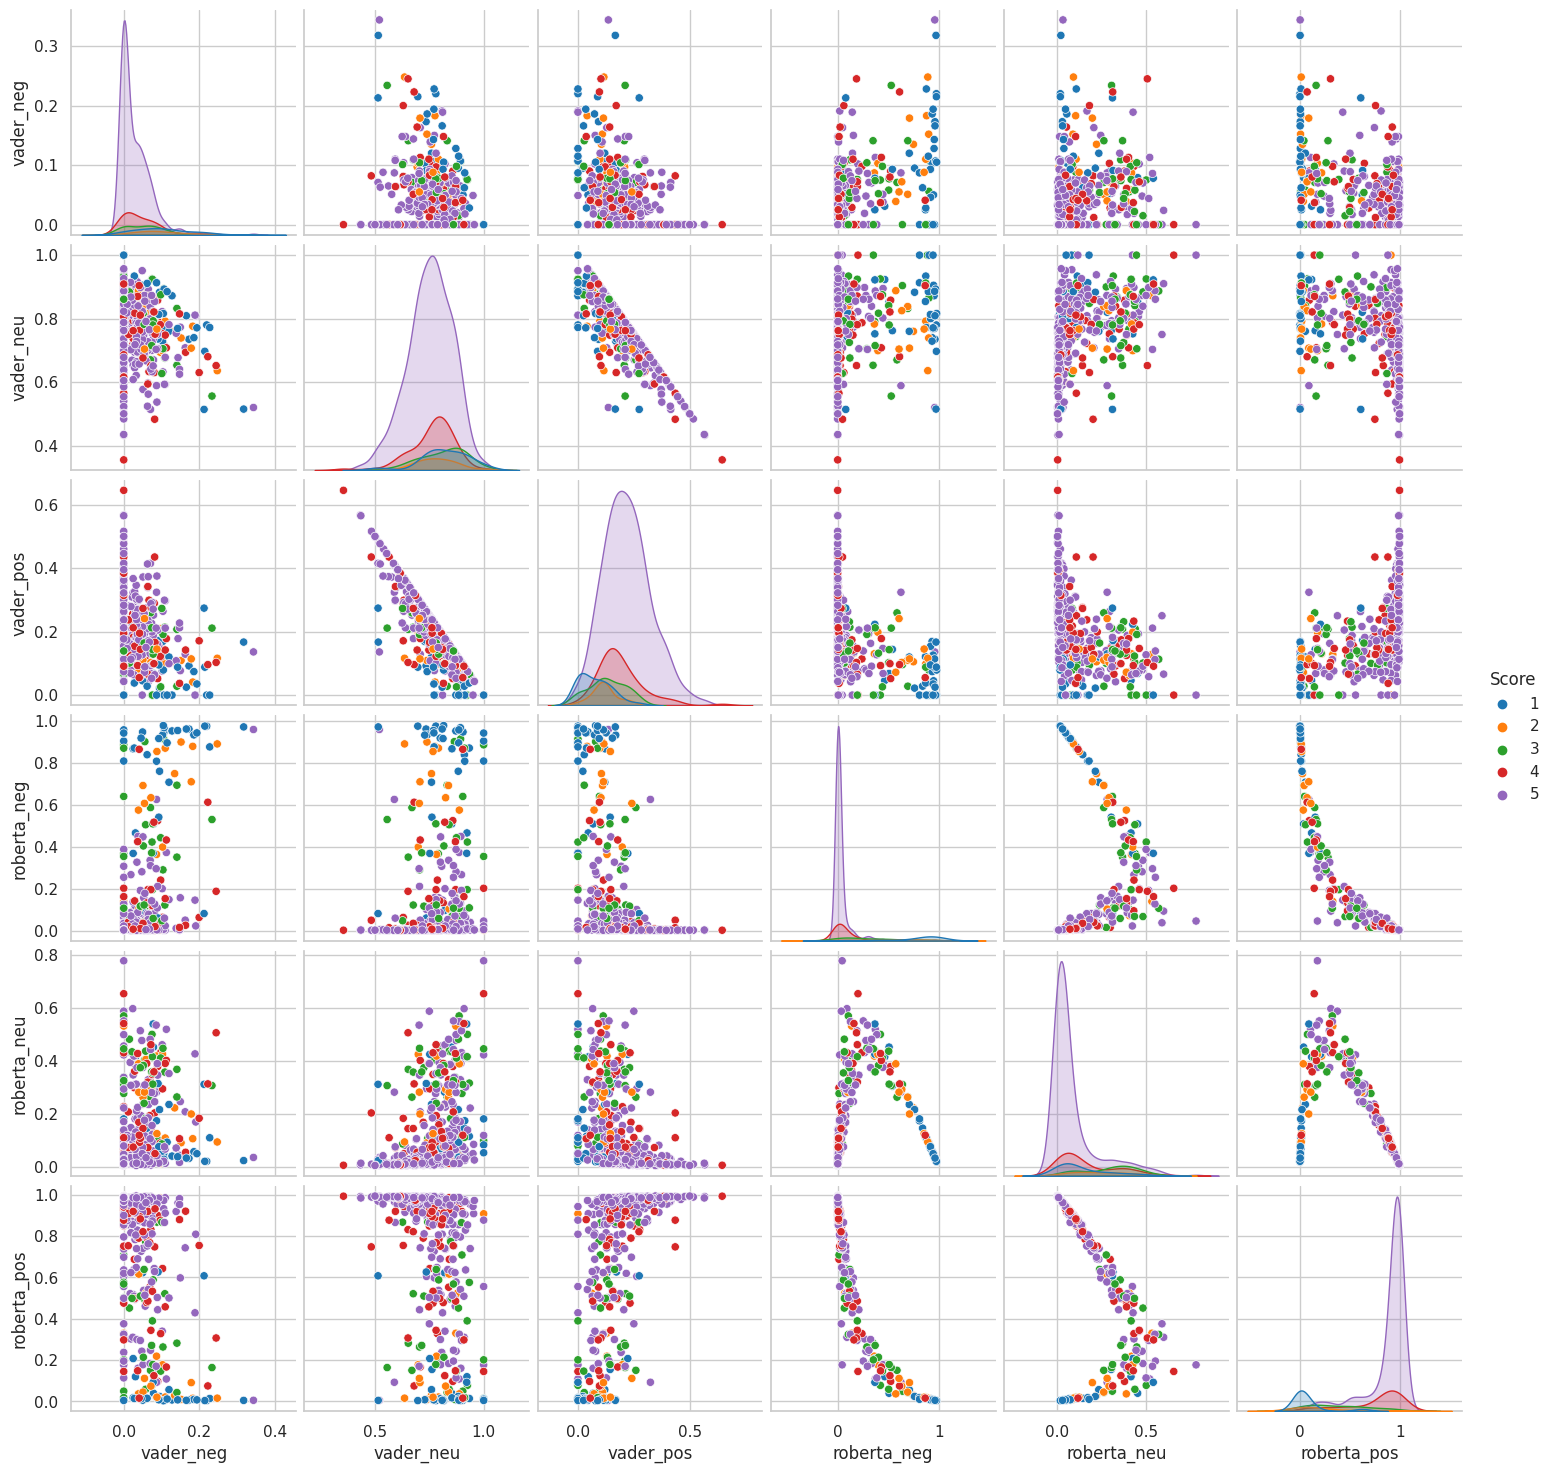

In [47]:
sns.set(style="whitegrid")

sns.pairplot(data=results_df,
            vars=['vader_neg', 'vader_neu', 'vader_pos', 'roberta_neg', 'roberta_neu', 'roberta_pos'],
            hue='Score',
            palette='tab10')
plt.show()

## **Step 4: Review Examples:**
Positive 1-Star and Negative 5-Star Reviews

In [48]:
results_df.query('Score == 1').sort_values('roberta_pos', ascending=False)['Text'].values[0]

'I felt energized within five minutes, but it lasted for about 45 minutes. I paid $3.99 for this drink. I could have just drunk a cup of coffee and saved my money.'

In [49]:
results_df.query('Score == 1').sort_values('vader_pos', ascending=False)['Text'].values[0]

'So we cancelled the order.  It was cancelled without any problem.  That is a positive note...'

## Negative sentiment 5-Star view

In [50]:
results_df.query('Score == 3').sort_values('roberta_neg', ascending=False)['Text'].values[0]

'I have always purchased Star-Kist tuna but thought I would try this brand for a change of pace. The taste of the tuna was not pleasant, too much basil and other spices for me.'

In [51]:
results_df.query('Score == 3').sort_values('vader_neg', ascending=False)['Text'].values[0]

'I love the flour however Amazon sent it with a book which broke a bag and made a mess. Customer sevice took care of the problem however it was a foolish way to ship the product.'

## **The Transformers Pipeline**

It is basically a quick and easy way to run sentiment pipeline.

In [52]:
from transformers import pipeline

In [53]:
sent_pipeline = pipeline('sentiment-analysis')

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [54]:
sent_pipeline('I love sentiment analysis!')

[{'label': 'POSITIVE', 'score': 0.9997853636741638}]

In [55]:
sent_pipeline('I love momos ;) and my Breeze <3')

[{'label': 'POSITIVE', 'score': 0.9995170831680298}]

In [56]:
sent_pipeline('Oops!')

[{'label': 'NEGATIVE', 'score': 0.856450080871582}]

In [57]:
sent_pipeline('booo')

[{'label': 'NEGATIVE', 'score': 0.9936267137527466}]

<h1 style="font-size:36px; font-family:Verdana, sans-serif; color:navy; text-align:center; font-weight:bold;">
    THE END :)
</h1>